# Task 11: Hierarchical Clustering

Machine Learning Fundamentals

## Goal
Build a Ward-linkage dendrogram for ten 2D points and obtain two agglomerative clusters.

## Setup
Run all cells from top to bottom with Python 3. Required packages: numpy, pandas, matplotlib, scipy, scikit-learn, and IPython.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display, Markdown

plt.rcParams.update({"figure.figsize": (7, 4), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 8)
pd.set_option("display.width", 88)
SEED = 42
print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.9.0


## Data and method
Use the ten coordinate pairs in the reference exercise. These are demonstration data, not measured observations. Euclidean distance and Ward linkage merge groups to minimize the increase in within-cluster squared distance. Both coordinates are assumed to have comparable units, so no scaling is applied.

        x     y
P1    4.0  21.0
P2    5.0  19.0
P3   10.0  24.0
P4    4.0  17.0
P5    3.0  16.0
P6   11.0  25.0
P7   14.0  24.0
P8    6.0  22.0
P9   10.0  21.0
P10  12.0  21.0


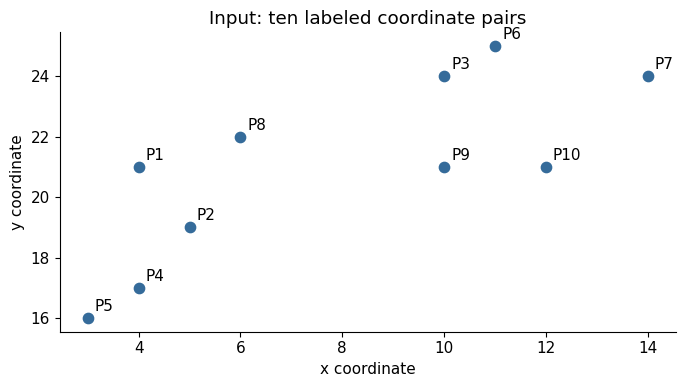

In [2]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score

points = np.array([
    [4, 21], [5, 19], [10, 24], [4, 17], [3, 16],
    [11, 25], [14, 24], [6, 22], [10, 21], [12, 21]
], dtype=float)
point_names = [f"P{i + 1}" for i in range(len(points))]
assert points.shape == (10, 2) and np.isfinite(points).all()
print(pd.DataFrame(points, index=point_names,
                   columns=["x", "y"]).to_string())
fig, ax = plt.subplots()
ax.scatter(points[:, 0], points[:, 1], color="#356b9a", s=55)
for name, (x, y) in zip(point_names, points):
    ax.annotate(name, (x, y), xytext=(5, 5), textcoords="offset points")
ax.set(xlabel="x coordinate", ylabel="y coordinate",
       title="Input: ten labeled coordinate pairs")
plt.tight_layout()
plt.show()

### Construct the dendrogram
The dashed line lies between the final two merge heights and produces two groups.

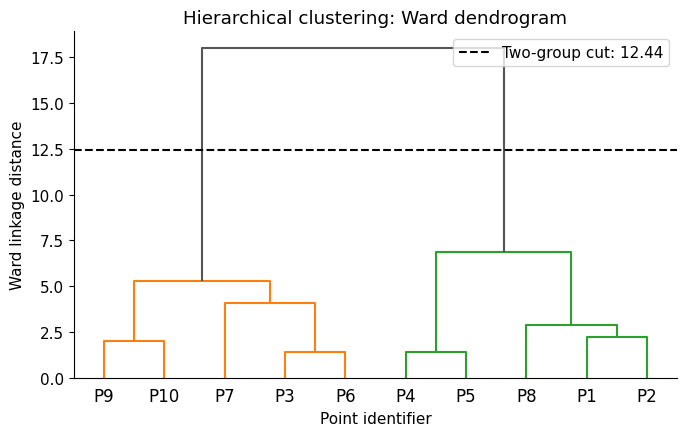

In [3]:
merge_tree = linkage(points, method="ward", metric="euclidean")
cut_height = (merge_tree[-2, 2] + merge_tree[-1, 2]) / 2
fig, ax = plt.subplots(figsize=(7, 4.5))
dendrogram(merge_tree, labels=point_names, color_threshold=cut_height,
           above_threshold_color="#555555", ax=ax)
ax.axhline(cut_height, color="black", linestyle="--",
           label=f"Two-group cut: {cut_height:.2f}")
ax.set(xlabel="Point identifier", ylabel="Ward linkage distance",
       title="Hierarchical clustering: Ward dendrogram")
ax.legend()
plt.tight_layout()
plt.show()

## Results
### Fit two groups and check agreement
Compare scikit-learn assignments with a cut of the SciPy tree. Adjusted Rand index handles arbitrary label numbering.

        x     y  cluster
P1    4.0  21.0        0
P2    5.0  19.0        0
P3   10.0  24.0        1
P4    4.0  17.0        0
P5    3.0  16.0        0
P6   11.0  25.0        1
P7   14.0  24.0        1
P8    6.0  22.0        0
P9   10.0  21.0        1
P10  12.0  21.0        1
Dendrogram / model agreement (ARI): 1.0
Silhouette score: 0.5639


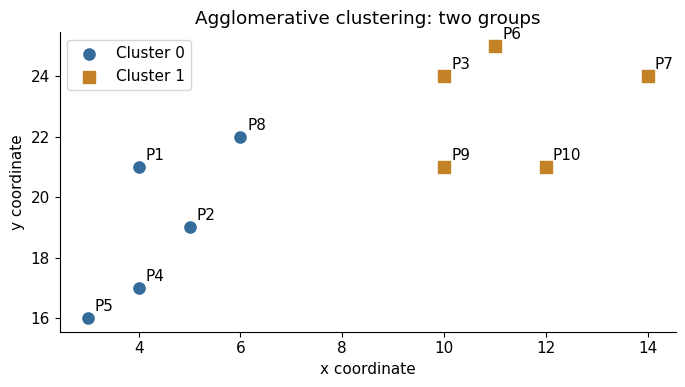

In [4]:
hierarchy = AgglomerativeClustering(n_clusters=2, linkage="ward")
assignments = hierarchy.fit_predict(points)
tree_groups = fcluster(merge_tree, cut_height, criterion="distance")
agreement = adjusted_rand_score(assignments, tree_groups)
assert agreement == 1.0
silhouette = silhouette_score(points, assignments)
membership = pd.DataFrame(points, columns=["x", "y"], index=point_names)
membership["cluster"] = assignments
print(membership.to_string())
print(f"Dendrogram / model agreement (ARI): {agreement:.1f}")
print(f"Silhouette score: {silhouette:.4f}")
fig, ax = plt.subplots()
for group, color, marker in zip(range(2), ["#356b9a", "#c48227"], ["o", "s"]):
    selected = assignments == group
    ax.scatter(points[selected, 0], points[selected, 1],
               color=color, marker=marker, s=65, label=f"Cluster {group}")
for name, (x, y) in zip(point_names, points):
    ax.annotate(name, (x, y), xytext=(5, 5), textcoords="offset points")
ax.set(xlabel="x coordinate", ylabel="y coordinate",
       title="Agglomerative clustering: two groups")
ax.legend()
plt.tight_layout()
plt.show()

## Takeaways

In [5]:
sizes = np.bincount(assignments)
display(Markdown(
    f"The two groups contain **{sizes[0]}** and **{sizes[1]}** points; "
    f"the silhouette score is **{silhouette:.3f}**. Cutting the dendrogram "
    "agrees exactly with the fitted model. Two groups are the exercise choice, "
    "not a claim of a uniquely optimal cluster count. Different scaling or "
    "linkage choices can change the hierarchy."
))

The two groups contain **5** and **5** points; the silhouette score is **0.564**. Cutting the dendrogram agrees exactly with the fitted model. Two groups are the exercise choice, not a claim of a uniquely optimal cluster count. Different scaling or linkage choices can change the hierarchy.

## Reference and reproducibility
Task scope reference: [Aishani's Task 11 notebook](https://github.com/aishani-dutta1397/Machine-Learning-Fundamentals-Work/blob/main/T11_Hierarchical_Cluster.ipynb). The reference was consulted for the exercise scope; the code, explanations, validation, and presentation here were independently written. Outputs are generated by the cells above. Cluster numbers, where used, are arbitrary identifiers.